In [1]:
# ALGORITHM PARAMETERS
# Max Token Saving period (s)
# Node may save up their Token budget for up to 2h to afford really expensive transmissions eventually.
SAVE_MAX = 3600*2

# Channel Utilization Target
CH_UTIL_TARGET = 0.25
# Channel Utilization Limit: Transmissions should get inhibitively expensive when approaching 40% ChUtil
CH_UTIL_LIMIT = 0.40
CONGESTION_PENALTY_MIN = 0.01
CONGESTION_PENALTY_MAX = 25
CONGESTION_PENALTY_AGGRESSION = 2

# Total distributed tokens (ms) per second
# Since we want a ChUtil of ~25%, we distribute 250 ms of airtime across all online nodes every second
TOKEN_RATE_TOTAL = CH_UTIL_TARGET * 1000


# Danger section of magic values I need to get rid of
# Broadcast Cost Power Law
FLOOD_POWER_LAW_EXPONENT = 1.5

# No of immediate neighbours
NEIGHBOUR_COUNT = 2.5

In [2]:
# Algorithm metrics
#def calcCongestionPenalty(ch_util_target, ch_util_limit, current_ch_util):
#    p_congestion = ch_util_limit / (ch_util_limit - current_ch_util) * (ch_util_limit - ch_util_target) / ch_util_limit
#    p_congestion = min(p_congestion, CONGESTION_PENALTY_MAX)
#    return p_congestion

def calcCongestionPenalty(ch_util_target, ch_util_limit, current_ch_util):
    if current_ch_util >= ch_util_limit:
        return CONGESTION_PENALTY_MAX

    if current_ch_util > ch_util_target:
        scarcity = (ch_util_limit - ch_util_target) / (ch_util_limit - current_ch_util) - 1
        penalty = scarcity * CONGESTION_PENALTY_AGGRESSION + 1
        penalty = min(penalty, CONGESTION_PENALTY_MAX)
        return penalty


    # if < target, linearly map 0...target to MIN...1.0
    return current_ch_util * (1 - CONGESTION_PENALTY_MIN) / ch_util_target + CONGESTION_PENALTY_MIN;

def calcHopFactor(routing_type, hop_start):
    if routing_type == 'next_hop':
        # Packet will be sent by up to (1 + hop_start) nodes
        # Then the ACK will travel approx. the same number of nodes back
        # Then the ACK-ACK will travel the same route as the original packet
        # The ACK packets are small, so we'll count them only half
        h_factor = (1 + hop_start) * 2
    elif routing_type == 'broadcast':
        h_factor = 1 + (NEIGHBOUR_COUNT* (hop_start**FLOOD_POWER_LAW_EXPONENT))
    else:
        raise ValueError("Invalid routing type. Must be 'next_hop' or 'broadcast'.")

    return h_factor

def calcRefillRate(token_rate_total, num_online_nodes):
    # We can safely assume there's SOME other nodes, even if we didn't hear from them yet.
    # It's a Mesh, after all.
    # limit num_online_nods to 5...250.
    num_online_nodes = min(max(5, num_online_nodes), 250)
    return token_rate_total / num_online_nodes

def calcBucketSize(token_rate_total, num_online_nodes):
    return calcRefillRate(token_rate_total, num_online_nodes) * SAVE_MAX

In [3]:
radio_configurations = [
    {"name": "Short Range / Turbo", "sf": 7, "bw": 500, "preamble_length": 16, "coding_rate": 5},
    {"name": "Short Range / Fast", "sf": 7, "bw": 250, "preamble_length": 16, "coding_rate": 5},
    {"name": "Short Range / Slow", "sf": 8, "bw": 250, "preamble_length": 16, "coding_rate": 5},
    {"name": "Medium Range / Fast", "sf": 9, "bw": 250, "preamble_length": 16, "coding_rate": 5},
    {"name": "Medium Range / Slow", "sf": 10, "bw": 250, "preamble_length": 16, "coding_rate": 5},
    {"name": "Long Range / Fast", "sf": 11, "bw": 250, "preamble_length": 16, "coding_rate": 5},
    {"name": "Long Range / Moderate", "sf": 11, "bw": 125, "preamble_length": 16, "coding_rate": 8},
    {"name": "Long Range / Slow", "sf": 12, "bw": 125, "preamble_length": 16, "coding_rate": 8},
]

In [4]:
'''import math

def calcPacketTime(payload_bytes, spreading_factor, bandwidth, preamble_length, coding_rate, is_dm):
    # Add Meshtastic header to payload_bytes
    payload_bytes += 16
    # Add PKC overhead to payload_bytes for DMs
    if is_dm:
        payload_bytes += 12
    bandwidth_hz = bandwidth * 1000.0
    head_disable = False # we currently always use the header
    tSym = (1 << spreading_factor) / bandwidth_hz
    lowDataOptEn = tSym > 16e-3
    tPreamble = (preamble_length + 4.25) * tSym
    numPayloadSym = 8 + max(math.ceil((8.0 * payload_bytes - 4 * spreading_factor + 28 + 16 - 20 * head_disable) / (4 * (spreading_factor - 2 * lowDataOptEn))) * coding_rate, 0.0)
    tPayload = numPayloadSym * tSym
    tPacket = tPreamble + tPayload
    msecs = tPacket * 1000
    return msecs'''

'import math\n\ndef calcPacketTime(payload_bytes, spreading_factor, bandwidth, preamble_length, coding_rate, is_dm):\n    # Add Meshtastic header to payload_bytes\n    payload_bytes += 16\n    # Add PKC overhead to payload_bytes for DMs\n    if is_dm:\n        payload_bytes += 12\n    bandwidth_hz = bandwidth * 1000.0\n    head_disable = False # we currently always use the header\n    tSym = (1 << spreading_factor) / bandwidth_hz\n    lowDataOptEn = tSym > 16e-3\n    tPreamble = (preamble_length + 4.25) * tSym\n    numPayloadSym = 8 + max(math.ceil((8.0 * payload_bytes - 4 * spreading_factor + 28 + 16 - 20 * head_disable) / (4 * (spreading_factor - 2 * lowDataOptEn))) * coding_rate, 0.0)\n    tPayload = numPayloadSym * tSym\n    tPacket = tPreamble + tPayload\n    msecs = tPacket * 1000\n    return msecs'

In [5]:
'''import math

def calcPacketTime(meshtastic_payload_bytes, spreading_factor, bandwidth_khz, lora_preamble_length_symbols, lora_payload_coding_rate, is_dm):

    #                                                 LoRa-Frame                                                 #
    #     LoRa-Preamble     # Sync-Word # LoRa-Header # LoRa-Header CRC #    LoRa-Payload     # LoRa-Payload CRC #
    #     |                             #    |                          #         |                              #
    #     |__ Configured length         #    |__ payload length         #         |__ Meshtastic Header          #
    #     |__ + fix 4 sym preamb.       #    |__ coding-rate            #         |__ Mestastic Payload          #
    #                                   #    |__ CRC-present?           #                                        #

    # 1. LoRa Preamble + Syncword
    lora_preamble_extra_symbols = 4
    lora_sync_word_symbols = 0.25
    lora_preamble_symbols = lora_preamble_length_symbols + lora_preamble_extra_symbols + lora_sync_word_symbols

    # 2. LoRa Header + LoRa Header CRC
    lora_header_enable = True # we currently always use the header
    lora_header_data_bits = 20 if lora_header_enable else 0
    lora_header_crc_bits = 8
    lora_header_bits = lora_header_data_bits + lora_header_crc_bits
    lora_header_coding_rate = 8 # LoRa header is always 4/8 coding rate
    lora_header_bits_per_symbol = 4 * spreading_factor # LDRO does not apply in the header

    # LoRa header is always 8 symbols for SF 7...12, but for clarity, here's why
    # math.ceil(28/(4*sf))*8
    # lora_header_symbols = math.ceil((lora_header_bits) / (lora_header_bits_per_symbol)) * lora_header_coding_rate
    lora_header_symbols = 8

    # 3. LoRa Payload + LoRa Payload CRC
    # 3a. Meshtastic Header

    # Add Meshtastic header to payload_bytes
    meshtastic_header_bytes = 16
    # Add PKC overhead to payload_bytes for DMs
    meshtastic_pkc_bytes = 12 if is_dm else 0

    # 3b. Meshtastic payload
    # Calculate actual meshtastic payload bits
    meshtastic_payload_bytes += meshtastic_header_bytes
    meshtastic_payload_bytes += meshtastic_pkc_bytes
    meshtastic_payload_bits = meshtastic_payload_bytes * 8.0

    # 3c. LoRa Payload CRC
    lora_payload_crc_bits = 16

    # Something about the magic diagonal interleaver I guess
    # SF 5 -> +8 bits
    #SF 6 -> +4 bits
    #SF 7 -> +0 bits
    #SF 8 -> -4 bits
    #SF 9 -> -8 bits
    #SF 10 -> -12 bits
    #SF 11 -> -16 bits
    #SF 12 -> -20 bits

    weird_correction_term = 28 - (4 * spreading_factor)

    lora_payload_bits = meshtastic_payload_bits + lora_payload_crc_bits + weird_correction_term

    bandwidth_hz = bandwidth_khz * 1000.0
    tSym = (1 << spreading_factor) / bandwidth_hz
    lowDataOptEn = tSym > 16e-3 # Use Semtech's LDRO if symbol_time > 16 ms
    lora_payload_bits_per_symbol = 4 * (spreading_factor - 2 * lowDataOptEn)
    lora_payload_symbols = math.ceil((lora_payload_bits) / (lora_payload_bits_per_symbol)) * lora_payload_coding_rate


    # String everything together
    total_symbols = lora_preamble_symbols + lora_header_symbols + lora_payload_symbols
    print(f"total_symbols: {total_symbols}")

    tPacket = total_symbols * tSym
    msecs = tPacket * 1000

    print(f"msecs: {msecs}")
    return msecs'''

'import math\n\ndef calcPacketTime(meshtastic_payload_bytes, spreading_factor, bandwidth_khz, lora_preamble_length_symbols, lora_payload_coding_rate, is_dm):\n\n    #                                                 LoRa-Frame                                                 #\n    #     LoRa-Preamble     # Sync-Word # LoRa-Header # LoRa-Header CRC #    LoRa-Payload     # LoRa-Payload CRC #\n    #     |                             #    |                          #         |                              #\n    #     |__ Configured length         #    |__ payload length         #         |__ Meshtastic Header          #\n    #     |__ + fix 4 sym preamb.       #    |__ coding-rate            #         |__ Mestastic Payload          #\n    #                                   #    |__ CRC-present?           #                                        #\n\n    # 1. LoRa Preamble + Syncword\n    lora_preamble_extra_symbols = 4\n    lora_sync_word_symbols = 0.25\n    lora_preamble_symbols = lora_p

In [6]:
import math

def calcPacketTime(
    meshtastic_payload_bytes: int,
    spreading_factor: int,
    bandwidth_khz: float,
    lora_preamble_length_symbols: int,
    lora_payload_coding_rate_denom: int,
    is_dm: bool,
    header_enabled: bool = True,
    payload_crc_enabled: bool = True,
):
    """
    Calculates the time-on-air for a LoRa packet based on the physical layer properties
    described in the paper "Design and Implementation of LoRa Physical Layer in GNU Radio".

    This calculation assumes an explicit header is used.
    """

    # Ensure coding rate denominator is valid
    if not 5 <= lora_payload_coding_rate_denom <= 8:
        raise ValueError("lora_payload_coding_rate_denom must be between 5 and 8 (for 4/5 to 4/8).")

    # Basic LoRa parameters
    bandwidth_hz = bandwidth_khz * 1000.0
    # Symbol Time (Ts) = 2^SF / BW
    t_sym = (2**spreading_factor) / bandwidth_hz
    # Low Data Rate Optimization (LDRO) is enabled if symbol time exceeds 16ms
    ldro_enabled = t_sym > 0.016

    # 1. Preamble Symbols (N_preamble)
    # As per Section 2.9, the full preamble consists of Nup configured upchirps,
    # 2 sync word symbols, and 2.25 downchirp symbols.
    n_preamble = lora_preamble_length_symbols + 4.25

    # 2. Header Symbols (N_header)
    # As per Section 2.7, an explicit header is always encoded with the most robust
    # coding rate (4/8) and takes a fixed 8 symbols.
    n_header = 8 if header_enabled else 0

    # 3. Payload Symbols (N_payload)
    # 3a. Calculate total bytes in the LoRa payload
    lora_payload_bytes = meshtastic_payload_bytes
    # Add Meshtastic protocol overhead (header + potential PKC overhead for DMs)
    lora_payload_bytes += 16  # Meshtastic header bytes
    lora_payload_bytes += 12 if is_dm else 0

    # 3b. Calculate the number of symbols needed for the payload
    # This is the core calculation based on the diagonal interleaver (Section 2.5)
    # and the encoding process (Section 2.4).

    # Number of bits in the payload, including the optional 16-bit CRC (Section 2.3)
    payload_bits = lora_payload_bytes * 8
    if payload_crc_enabled:
        payload_bits += 16

    # Each codeword encodes a 4-bit nibble.
    payload_nibbles = math.ceil(payload_bits / 4.0)

    # The number of codewords that can be processed in parallel by the interleaver.
    # This is SF normally, or SF-2 if LDRO is active (Section 2.5).
    bits_per_symbol_group = spreading_factor - 2 if ldro_enabled else spreading_factor

    # How many blocks of symbols are needed to transmit all the nibbles.
    num_symbol_blocks = math.ceil(payload_nibbles / bits_per_symbol_group)

    # Each symbol block requires 'lora_payload_coding_rate_denom' symbols to be transmitted.
    # e.g., for a 4/5 rate, 5 symbols are sent for every 4 data nibbles.
    n_payload = num_symbol_blocks * lora_payload_coding_rate_denom

    # In some edge cases with small payloads and high SF, the formula might yield a negative
    # number of symbols if we used the all-in-one implicit header formula. This component-based
    # method is safer, but we ensure it's not negative.
    n_payload = max(0, n_payload)


    # 4. Total Packet Calculation
    total_symbols = n_preamble + n_header + n_payload

    t_packet_seconds = total_symbols * t_sym

    # For debugging and verification
    # print(f"SF: {spreading_factor}, BW: {bandwidth_khz}kHz, CR: 4/{lora_payload_coding_rate_denom}, PL: {meshtastic_payload_bytes}B")
    # print(f"  Symbol Time: {t_sym*1000:.3f} ms, LDRO enabled: {ldro_enabled}")
    # print(f"  Preamble Symbols: {n_preamble}, Header Symbols: {n_header}, Payload Symbols: {n_payload}")
    # print(f"  Total Symbols: {total_symbols}")
    # print(f"  Time on Air: {t_packet_seconds * 1000:.2f} ms")

    return t_packet_seconds * 1000

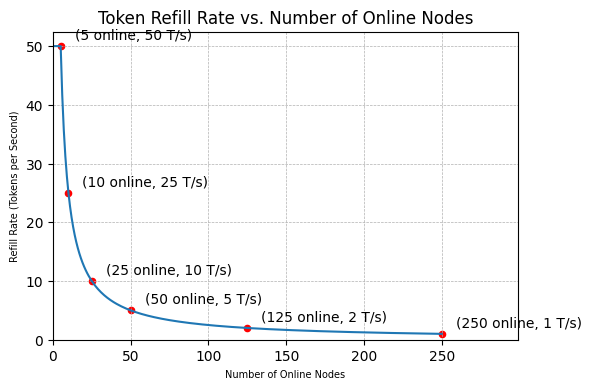

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of online nodes
num_online_nodes_range = np.arange(0, 251)

# Calculate the refill rate for each number of online nodes
refill_rates = [calcRefillRate(TOKEN_RATE_TOTAL, num_nodes) for num_nodes in num_online_nodes_range]

# Create the plot
plt.figure(figsize=(6, 4))
plt.plot(num_online_nodes_range, refill_rates, '-')

# Add markers at 5, 10, 20, 30, 50, 100, 150, 200 and 250 online node
markers = [5, 10, 25, 50, 125, 250]
for marker in markers:
    plt.scatter(marker, calcRefillRate(TOKEN_RATE_TOTAL, marker), color='red', marker='o', s=20)
    # Add a label the shows the refill rate at this point like this "(5 online, 200 T/s)""
    plt.annotate(f'({marker} online, {calcRefillRate(TOKEN_RATE_TOTAL, marker):.0f} T/s)', (marker, calcRefillRate(TOKEN_RATE_TOTAL, marker)), textcoords="offset points", xytext=(10, 5), ha='left')


# Formatting the plot
plt.title('Token Refill Rate vs. Number of Online Nodes', fontsize=12)
plt.xlabel('Number of Online Nodes', fontsize=7)
plt.ylabel('Refill Rate (Tokens per Second)', fontsize=7)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlim(0, 299)
plt.ylim(bottom=0)

plt.show()

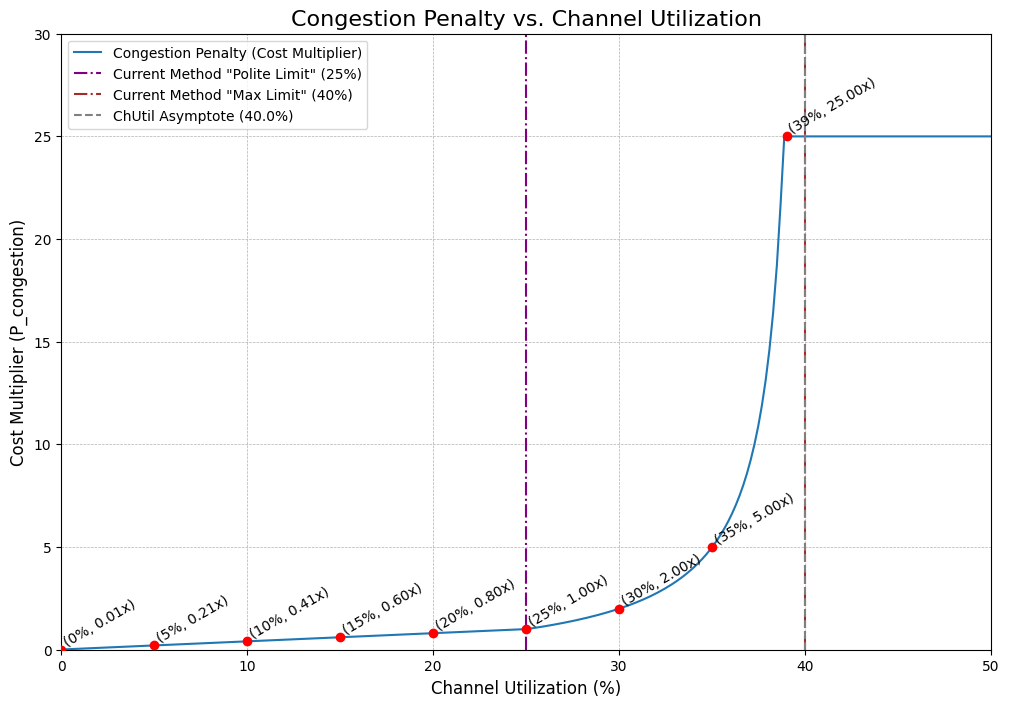

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Create a range of current channel utilization values
# then remove last value to avoid div/0 issue
current_cu = np.linspace(0.0, 1.0, 500)[:-1]

# Calculate the P_congestion for each utilization value
p_congestion = [calcCongestionPenalty(CH_UTIL_TARGET, CH_UTIL_LIMIT, cu) for cu in current_cu]

# Define old method thresholds (in percentage)
old_method_max_channel_util_percent = 40
old_method_polite_channel_util_percent = 25

# Create the plot
plt.figure(figsize=(12, 8))
plt.plot(current_cu * 100, p_congestion, label='Congestion Penalty (Cost Multiplier)')

# Add key points for context
# Marker at every 5% up until CH_UTIL_LIMIT - 1%
key_utilizations = [i / 100 for i in range(0, int(CH_UTIL_LIMIT * 100), 5)] # every 5%
key_utilizations.append(CH_UTIL_LIMIT - 0.01)
key_penalties = [calcCongestionPenalty(CH_UTIL_TARGET, CH_UTIL_LIMIT, cu) for cu in key_utilizations]
plt.scatter(np.array(key_utilizations) * 100, key_penalties, color='red', zorder=5)

# Annotate the key points
for u, p in zip(key_utilizations, key_penalties):
    #plt.text(u * 100 + 1, p, f'({u*100:.0f}%, {p:.1f}x)', verticalalignment='center')
    # rotate annotations to 30 deg
    plt.text(u * 100, p, f'({u*100:.0f}%, {p:.2f}x)', verticalalignment='bottom', rotation=30)

# Add vertical lines for old method thresholds
plt.axvline(x=old_method_polite_channel_util_percent, color='purple', linestyle='-.', label=f'Current Method "Polite Limit" ({old_method_polite_channel_util_percent}%)')
plt.axvline(x=old_method_max_channel_util_percent, color='brown', linestyle='-.', label=f'Current Method "Max Limit" ({old_method_max_channel_util_percent}%)')


# Formatting the plot
plt.title('Congestion Penalty vs. Channel Utilization', fontsize=16)
plt.xlabel('Channel Utilization (%)', fontsize=12)
plt.ylabel('Cost Multiplier (P_congestion)', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, CONGESTION_PENALTY_MAX + 5) # Set Y-axis limit to better show the curve's shape up to the 50x mark
plt.xlim(0, 50) # Set X-axis limit to 50%
plt.axvline(x=CH_UTIL_LIMIT*100, color='grey', linestyle='--', label='ChUtil Asymptote (' + str(CH_UTIL_LIMIT*100) + '%)')
plt.legend()
plt.show()

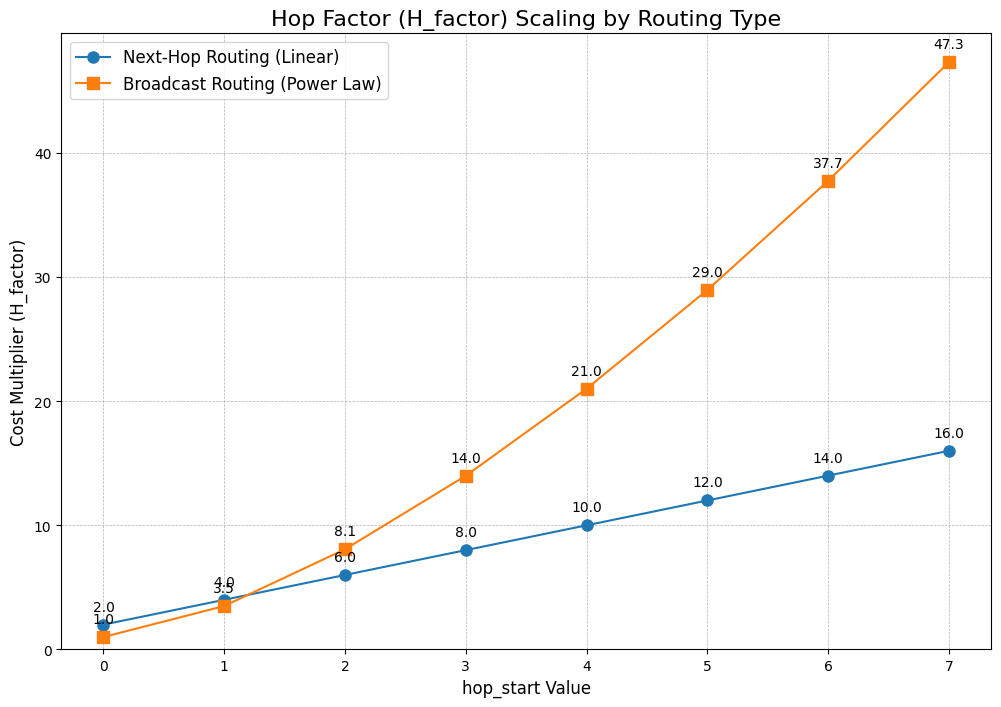

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define the hop_start range
hop_start = np.arange(0, 8) # Creates an array [0, 1, 2, 3, 4, 5, 6, 7]

# Calculate the H_factor for both routing types
h_factor_next_hop = calcHopFactor('next_hop', hop_start)
h_factor_broadcast = calcHopFactor('broadcast', hop_start)

# Create the plot
plt.figure(figsize=(12, 8))
plt.plot(hop_start, h_factor_next_hop, 'o-', label='Next-Hop Routing (Linear)', markersize=8)
plt.plot(hop_start, h_factor_broadcast, 's-', label='Broadcast Routing (Power Law)', markersize=8)

# Add value labels to the points for clarity
for i, txt in enumerate(h_factor_next_hop):
    plt.annotate(f'{txt:.1f}', (hop_start[i], h_factor_next_hop[i]), textcoords="offset points", xytext=(0,10), ha='center')

for i, txt in enumerate(h_factor_broadcast):
    plt.annotate(f'{txt:.1f}', (hop_start[i], h_factor_broadcast[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Formatting the plot
plt.title('Hop Factor (H_factor) Scaling by Routing Type', fontsize=16)
plt.xlabel('hop_start Value', fontsize=12)
plt.ylabel('Cost Multiplier (H_factor)', fontsize=12)
plt.xticks(hop_start) # Ensure we have ticks for every integer hop_start
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)
plt.ylim(bottom=0)
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plotPacketAffordability(num_online_nodes, current_cu, radio_preset):
  # --- 2. Calculate Derived Constants ---
  TOKEN_RATE_R = calcRefillRate(TOKEN_RATE_TOTAL, num_online_nodes)
  P_CONGESTION = calcCongestionPenalty(CH_UTIL_TARGET, CH_UTIL_LIMIT, current_cu)
  AFFORDABILITY_LIMIT_MINS = SAVE_MAX / 60
  B_MAX = calcBucketSize(TOKEN_RATE_TOTAL, num_online_nodes)

  # --- 3. Define Scenarios ---
  # from the list, get the Long Range / Fast configuration by name
  radio_config = next(config for config in radio_configurations if config["name"] == radio_preset)

  # Example Message Sizes
  EMPTY_PAYLOAD_BYTES = 0
  TELEMETRY_PAYLOAD_BYTES = 25
  CHANNEL_TEXT_PAYLOAD_BYTES = 100
  DM_TEXT_PAYLOAD_BYTES = 100
  NODE_INFO_PAYLOAD_BYTES = 100
  MAX_PAYLOAD_BYTES = 200

  dm_text_airtime = calcPacketTime(DM_TEXT_PAYLOAD_BYTES, radio_config["sf"], radio_config["bw"], radio_config["preamble_length"], radio_config["coding_rate"], is_dm=True)
  channel_text_airtime = calcPacketTime(CHANNEL_TEXT_PAYLOAD_BYTES, radio_config["sf"], radio_config["bw"], radio_config["preamble_length"], radio_config["coding_rate"], is_dm=False)
  telemetry_airtime = calcPacketTime(TELEMETRY_PAYLOAD_BYTES, radio_config["sf"], radio_config["bw"], radio_config["preamble_length"], radio_config["coding_rate"], is_dm=False)
  node_info_airtime = calcPacketTime(NODE_INFO_PAYLOAD_BYTES, radio_config["sf"], radio_config["bw"], radio_config["preamble_length"], radio_config["coding_rate"], is_dm=False)
  empty_payload_airtime = calcPacketTime(EMPTY_PAYLOAD_BYTES, radio_config["sf"], radio_config["bw"], radio_config["preamble_length"], radio_config["coding_rate"], is_dm=False)
  max_payload_airtime = calcPacketTime(MAX_PAYLOAD_BYTES, radio_config["sf"], radio_config["bw"], radio_config["preamble_length"], radio_config["coding_rate"], is_dm=False)

  '''scenarios = {
      f"DM Text ({dm_text_airtime:.0f} ms, next-hop)": {
          "airtime": dm_text_airtime,
          "type": "next_hop",
          "style": "o-",
          "color": "blue"
      },
      f"Channel Text ({channel_text_airtime:.0f} ms, broadcast)": {
          "airtime": channel_text_airtime,
          "type": "broadcast",
          "style": "s-",
          "color": "orange"
      },
      f"Telemetry ({telemetry_airtime:.0f} ms, broadcast)": {
          "airtime": telemetry_airtime,
          "type": "broadcast",
          "style": "^-",
          "color": "green"
      },
      f"Node Info ({node_info_airtime:.0f} ms, broadcast)": {
          "airtime": node_info_airtime,
          "type": "broadcast",
          "style": "x-",
          "color": "red"
      }
  }'''

  scenarios = {
      f"DM Text ({DM_TEXT_PAYLOAD_BYTES} bytes, {dm_text_airtime:.0f} ms, next-hop routed)": {
          "airtime": dm_text_airtime,
          "type": "next_hop",
          "style": "o-",
          "color": "blue"
      },
      f"Broadcast (Channel Text, NodeInfo) ({CHANNEL_TEXT_PAYLOAD_BYTES} bytes, {channel_text_airtime:.0f} ms, flood routed)": {
          "airtime": channel_text_airtime,
          "type": "broadcast",
          "style": "s-",
          "color": "orange"
      },
      f"Broadcast (Empty Payload) ({empty_payload_airtime:.0f} ms, flood routed)": {
          "airtime": empty_payload_airtime,
          "type": "broadcast",
          "style": "^-",
          "color": "green"
      },
      f"Broadcast (Max Payload) ({MAX_PAYLOAD_BYTES} bytes, {max_payload_airtime:.0f} ms, flood routed)": {
          "airtime": max_payload_airtime,
          "type": "broadcast",
          "style": "x-",
          "color": "red"
      }

  }

  # --- 4. Calculate Data for Plotting ---
  hop_start_range = np.arange(0, 8)

  plt.figure(figsize=(14, 10))

  for name, params in scenarios.items():
      times_in_minutes = []
      burst_counts = []
      for hop in hop_start_range:
          h_factor = calcHopFactor(params["type"], hop)
          c_base = params["airtime"] * h_factor
          total_cost = c_base * P_CONGESTION
          time_seconds = total_cost / TOKEN_RATE_R
          time_minutes = time_seconds / 60

          burst_count = np.floor(B_MAX / total_cost) if total_cost > 0 else np.inf
          burst_counts.append(burst_count)
          times_in_minutes.append(time_minutes)

      times_in_minutes = np.array(times_in_minutes) # Convert to numpy array for easier comparison

      # Plot the line segments and markers
      for i in range(len(hop_start_range)):
          x, y = hop_start_range[i], times_in_minutes[i]
          marker = params["style"][0] # Get marker style from scenario

          if y <= AFFORDABILITY_LIMIT_MINS:
              # Marker is below or at the limit - plot in scenario color
              plt.scatter(x, y, color=params["color"], s=64, zorder=5, marker=marker)
          else:
              # Marker is above the limit - plot in grey
              plt.scatter(x, y, color='grey', s=64, zorder=5, marker=marker)

          # Add burst count annotation
          burst_text = f'{int(burst_counts[i])}' if burst_counts[i] != np.inf else 'inf'
          plt.annotate(burst_text, (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)


          if i < len(hop_start_range) - 1:
              x_next, y_next = hop_start_range[i+1], times_in_minutes[i+1]

              # Determine segment color and style
              if y <= AFFORDABILITY_LIMIT_MINS and y_next <= AFFORDABILITY_LIMIT_MINS:
                  # Both points below or at the limit - plot segment in scenario color
                  plt.plot([x, x_next], [y, y_next], linestyle='-', color=params["color"], linewidth=2)
              elif y > AFFORDABILITY_LIMIT_MINS and y_next > AFFORDABILITY_LIMIT_MINS:
                  # Both points above the limit - plot segment in grey dashed
                  plt.plot([x, x_next], [y, y_next], linestyle='--', color='grey', linewidth=2)
              else:
                  # Segment crosses the limit - plot in grey dashed
                  plt.plot([x, x_next], [y, y_next], linestyle='--', color='grey', linewidth=2)

      # Plot a proxy line with the correct color and label for the legend
      # This line is not visible on the plot itself, but is used for the legend entry
      plt.plot([], [], params["style"], label=name, markersize=8, color=params["color"])

  # Custom y-axis tick formatter to show seconds, minutes, or hours
  def time_formatter(y, pos):
      if y < 1:
          return f"{y*60:.0f} s"
      elif y < 60:
          return f"{y:.0f} m"
      else:
          return f"{y/60:.1f} h"

  # --- 5. Formatting the Plot ---
  plt.axhline(y=AFFORDABILITY_LIMIT_MINS, color='grey', linestyle='--')
  #plt.text(hop_start_range[-1], SAVE_MAX, f'Save Max ({SAVE_MAX}ms)',
  #         verticalalignment='bottom', horizontalalignment='right', color='grey', fontsize=10)

  # Add text for SAVE_MAX using time_formatter
  plt.text(hop_start_range[3], AFFORDABILITY_LIMIT_MINS, f'Affordability Limit ({time_formatter(AFFORDABILITY_LIMIT_MINS, 0)})',
          verticalalignment='top', horizontalalignment='left', color='black', fontsize=10)

  # Add horizontal lines for 1 minute and 1 hour
  plt.axhline(y=1, color='black', linestyle='-')
  plt.axhline(y=60, color='black', linestyle='-')

  # Add vertical labels for time regimes
  plt.text(hop_start_range[-1] + 0.2, 0.5, 'Seconds', verticalalignment='center', horizontalalignment='left', rotation='vertical', color='grey', fontsize=10)
  plt.text(hop_start_range[-1] + 0.2, 10, 'Minutes', verticalalignment='center', horizontalalignment='left', rotation='vertical', color='grey', fontsize=10)
  # Calculate the midpoint for the "Hours" label on the log scale
  hours_label_y = np.sqrt(60 * AFFORDABILITY_LIMIT_MINS)
  plt.text(hop_start_range[-1] + 0.2, hours_label_y, 'Hours', verticalalignment='center', horizontalalignment='left', rotation='vertical', color='grey', fontsize=10)


  plt.title('Time to Afford Packets (' + str(num_online_nodes) + ' Nodes @ ' + str(current_cu * 100) + '% ChUtil)', fontsize=16)
  plt.xlabel('hop_start Value', fontsize=12)
  plt.ylabel('Time to Afford', fontsize=12) # Changed label since units are in ticks
  plt.xticks(hop_start_range)
  plt.grid(True, which='both', linestyle='--', linewidth=0.5)
  plt.legend(fontsize=11, loc='lower right') # Added loc='lower right' to move the legend
  plt.ylim(bottom=1/60)

  # Set Y-axis to logarithmic scale
  plt.yscale('log')



  plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(time_formatter))
  plt.gca().yaxis.set_minor_formatter(ticker.FuncFormatter(time_formatter))

  # Removed plt.show()

In [11]:
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# Create sliders
num_online_nodes_slider = IntSlider(min=5, max=250, step=1, value=10, description='Online Nodes:', layout=widgets.Layout(width='500px'))
current_cu_slider = FloatSlider(min=0, max=CH_UTIL_LIMIT-0.01, step=0.01, value=0.05, description='Current ChUtil:', layout=widgets.Layout(width='500px'))

# Create dropdown for radio preset
radio_preset_options = [config["name"] for config in radio_configurations]
radio_preset_dropdown = Dropdown(options=radio_preset_options, description='Radio Preset:', value=radio_preset_options[5], layout=widgets.Layout(width='500px'))

# Use interact to link sliders and dropdown to the plotting function
interact(plotPacketAffordability, num_online_nodes=num_online_nodes_slider, current_cu=current_cu_slider, radio_preset=radio_preset_dropdown, continuous_update=False);

interactive(children=(IntSlider(value=10, description='Online Nodes:', layout=Layout(width='500px'), max=250, …

In [12]:
# Estimate the resulting channel utilization if the specified number of nodes all send the most expensive broadcast as often as the time to afford allows



In [13]:
def estimate_resulting_ch_util(num_online_nodes, current_cu, radio_config):
  # Estimate the resulting channel utilization if the specified number of nodes all send the most expensive broadcast as often as the time to afford allows

  # Get the radio configuration for 'Long Range / Fast'
  radio_config_lr_fast = next(config for config in radio_configurations if config["name"] == "Long Range / Fast")

  # Calculate the airtime for the broadcast message
  broadcast_payload_bytes = 50 # Using Channel Text payload size as representative
  broadcast_airtime = calcPacketTime(broadcast_payload_bytes, radio_config_lr_fast["sf"], radio_config_lr_fast["bw"], radio_config_lr_fast["preamble_length"], radio_config_lr_fast["coding_rate"], is_dm=False)

  # Calculate the refill rate and bucket size for the example number of online nodes
  refill_rate = calcRefillRate(TOKEN_RATE_TOTAL, num_online_nodes)
  bucket_size = calcBucketSize(TOKEN_RATE_TOTAL, num_online_nodes)

  # calculate max affordable hop_start by iterating over 0...7 and calculating the total_cost until its smaller than the bucket_size
  hop_start = 0
  total_cost = 0
  c_base_broadcast = 0
  p_congestion = 0
  total_cost = 0
  while (total_cost < bucket_size) & (hop_start < 7):
    hop_start += 1
    h_factor_broadcast = calcHopFactor('broadcast', hop_start)
    c_base_broadcast = broadcast_airtime * h_factor_broadcast
    p_congestion_example = calcCongestionPenalty(CH_UTIL_TARGET, CH_UTIL_LIMIT, current_cu)
    total_cost = c_base_broadcast * p_congestion_example

  # Calculate the time to afford one broadcast packet in seconds
  # This is the total cost divided by the refill rate
  time_to_afford_broadcast_seconds = total_cost / refill_rate

  # Calculate how many times a node can send this packet per second on average
  # This is the inverse of the time to afford in seconds
  packets_per_second_per_node = 1 / time_to_afford_broadcast_seconds

  # Estimate the total airtime consumed per second by all nodes sending this broadcast as often as possible
  # This is the number of online nodes * packets per second per node * base airtime of the packet (without hop factor or congestion)
  # We use the base airtime here because the hop factor and congestion penalty are already factored into the 'time to afford'
  estimated_ch_util_ms_per_second = num_online_nodes * packets_per_second_per_node * broadcast_airtime * h_factor_broadcast

  # Convert the estimated channel utilization to a percentage
  estimated_ch_util = (estimated_ch_util_ms_per_second / 1000)

  update_rate_seconds = 7200 / num_online_nodes


  print(f"--- Estimation for {num_online_nodes} Nodes @ {current_cu*100:.1f}% Initial ChUtil ---")
  print(f"Most expensive broadcast packet airtime (base): {broadcast_airtime:.2f} ms")
  print(f"Hop factor for hop_start={hop_start}: {h_factor_broadcast:.2f}")
  print(f"Base cost of broadcast packet: {c_base_broadcast:.2f} ms")
  print(f"Congestion penalty: {p_congestion_example:.2f}x")
  print(f"Total cost of broadcast packet: {total_cost:.2f} ms")
  print(f"Refill rate per node: {refill_rate:.2f} ms/s")
  print(f"Time to afford one broadcast packet: {time_to_afford_broadcast_seconds:.2f} seconds")
  print(f"Average packets per hour per node: {3600*packets_per_second_per_node:.4f}")
  print(f"Estimated total airtime consumed per second: {estimated_ch_util_ms_per_second:.2f} ms")
  print(f"Estimated resulting channel utilization: {100*estimated_ch_util:.2f}%")
  print(f"Estimated update rate: {update_rate_seconds:.2f} seconds")


  return estimated_ch_util, update_rate_seconds, hop_start
  #

--- Estimation for 10 Nodes @ 5.0% Initial ChUtil ---
Most expensive broadcast packet airtime (base): 763.90 ms
Hop factor for hop_start=7: 47.30
Base cost of broadcast packet: 36133.15 ms
Congestion penalty: 0.21x
Total cost of broadcast packet: 7515.70 ms
Refill rate per node: 25.00 ms/s
Time to afford one broadcast packet: 300.63 seconds
Average packets per hour per node: 11.9749
Estimated total airtime consumed per second: 1201.92 ms
Estimated resulting channel utilization: 120.19%
Estimated update rate: 720.00 seconds
--- Estimation for 10 Nodes @ 16.5% Initial ChUtil ---
Most expensive broadcast packet airtime (base): 763.90 ms
Hop factor for hop_start=7: 47.30
Base cost of broadcast packet: 36133.15 ms
Congestion penalty: 0.66x
Total cost of broadcast packet: 23998.25 ms
Refill rate per node: 25.00 ms/s
Time to afford one broadcast packet: 959.93 seconds
Average packets per hour per node: 3.7503
Estimated total airtime consumed per second: 376.41 ms
Estimated resulting channel u

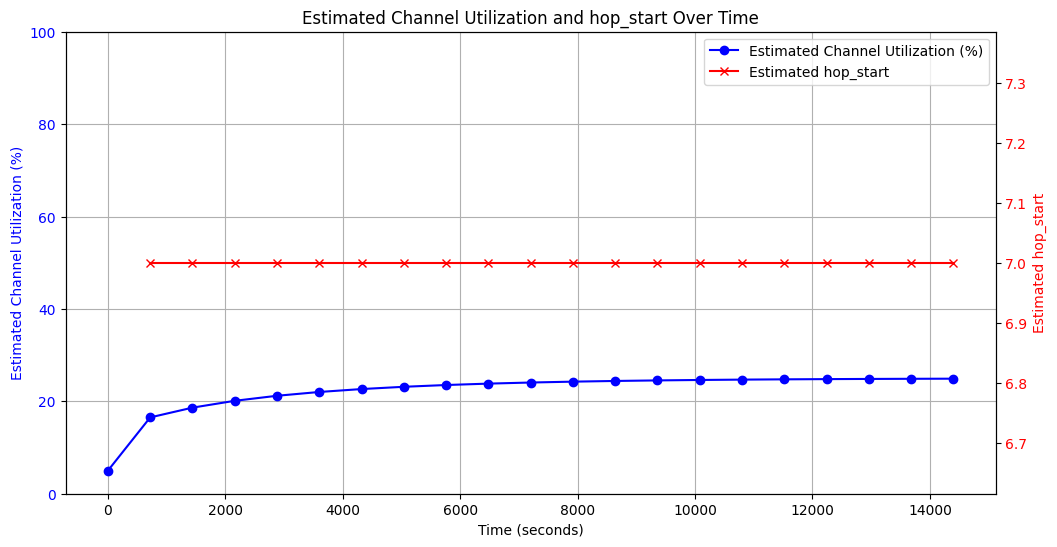


Final Estimated Channel Utilization after 20 iterations: 24.90%
Final Estimated hop_start after 20 iterations: 7.00


In [14]:
import matplotlib.pyplot as plt

estimated_resulting_chutil = current_cu_slider.value
num_online_nodes = num_online_nodes_slider.value
radio_preset = radio_preset_dropdown.value

# Lists to store the historical data for plotting
chutil_history = [estimated_resulting_chutil]
time_history = [0] # Start time at 0
hop_start_history = [] # List to store hop_start values

# Assuming each iteration represents a time step equal to the update rate
current_time = 0

# Run the estimation for 4 h
i = 0

while current_time < 4 * 3600:
  # estimate chutil is this ran for the full 2h cycle
  next_estimated_resulting_chutil, update_rate, hop_start = estimate_resulting_ch_util(num_online_nodes, estimated_resulting_chutil, radio_preset)

  # estimate the next chutil measurement
  # This is a simplified model where the channel utilization moves towards the estimated resulting chutil
  # based on the proportion of the update rate to the SAVE_MAX period (7200 seconds)
  estimated_resulting_chutil = estimated_resulting_chutil * (1 - update_rate/SAVE_MAX) + next_estimated_resulting_chutil * update_rate/SAVE_MAX

  current_time += update_rate # Increment time by the update rate

  chutil_history.append(estimated_resulting_chutil)
  time_history.append(current_time)
  hop_start_history.append(hop_start) # Record hop_start value
  i += 1

# Plot the timeline of estimated channel utilization and hop_start
plt.figure(figsize=(12, 6))
ax1 = plt.gca() # Get the current axes

ax1.plot(time_history, [cu * 100 for cu in chutil_history], marker='o', linestyle='-', label='Estimated Channel Utilization (%)', color='blue')

ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Estimated Channel Utilization (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)
ax1.set_ylim(0, 100) # Set y-axis limit to 0-100%

# Create a secondary y-axis for hop_start
ax2 = ax1.twinx()
ax2.plot(time_history[1:], hop_start_history, marker='x', linestyle='-', label='Estimated hop_start', color='red') # Start from the second element as hop_start is calculated in the loop

ax2.set_ylabel('Estimated hop_start', color='red')
ax2.tick_params(axis='y', labelcolor='red')


plt.title('Estimated Channel Utilization and hop_start Over Time')
# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

# Print the final estimated channel utilization and hop_start
print(f"\nFinal Estimated Channel Utilization after {i} iterations: {estimated_resulting_chutil*100:.2f}%")
print(f"Final Estimated hop_start after {i} iterations: {hop_start_history[-1]:.2f}")